<a href="https://colab.research.google.com/github/anirudh8926/Python-Code/blob/main/micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [4]:
def f(x):
  return m.log(x)


In [5]:
k = np.arange(0.1, 10, 0.1)
l = np.log10(k)
l

array([-1.        , -0.69897   , -0.52287875, -0.39794001, -0.30103   ,
       -0.22184875, -0.15490196, -0.09691001, -0.04575749,  0.        ,
        0.04139269,  0.07918125,  0.11394335,  0.14612804,  0.17609126,
        0.20411998,  0.23044892,  0.25527251,  0.2787536 ,  0.30103   ,
        0.32221929,  0.34242268,  0.36172784,  0.38021124,  0.39794001,
        0.41497335,  0.43136376,  0.44715803,  0.462398  ,  0.47712125,
        0.49136169,  0.50514998,  0.51851394,  0.53147892,  0.54406804,
        0.5563025 ,  0.56820172,  0.5797836 ,  0.59106461,  0.60205999,
        0.61278386,  0.62324929,  0.63346846,  0.64345268,  0.65321251,
        0.66275783,  0.67209786,  0.68124124,  0.69019608,  0.69897   ,
        0.70757018,  0.71600334,  0.72427587,  0.73239376,  0.74036269,
        0.74818803,  0.75587486,  0.76342799,  0.77085201,  0.77815125,
        0.78532984,  0.79239169,  0.79934055,  0.80617997,  0.81291336,
        0.81954394,  0.8260748 ,  0.83250891,  0.83884909,  0.84

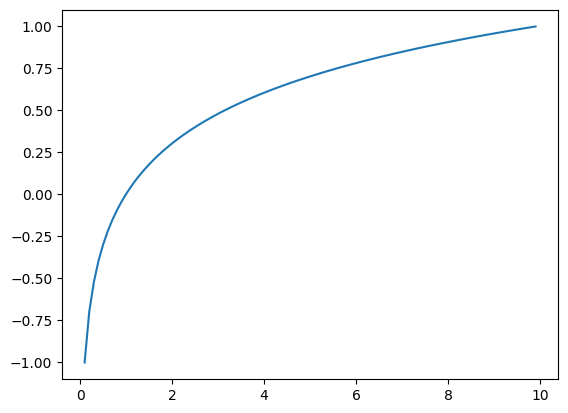

In [6]:
plt.plot(k, l)

In [7]:
#a
class Value:
  def __init__(self, data, _children=(), _op="", label = ""):
    self._prev = set(_children)
    self.data = data
    self._op = _op
    self.label = label
    self.grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __pow__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data**(other.data), (self,))
    def _backward():
      self.grad = other * (self.data ** (other +  (-1))) * out.grad
    out._backward = _backward
    return out

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), "+")
    def _backward():
      self.grad += out.grad
      other.grad += out.grad
    out._backward = _backward
    return out

  def __radd__(self, other):
    return self + other

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), "*")
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def __rmul__(self, other):
    return  self * other

  def __truediv__(self, other):                                 # python default division operator is called is __truediv__
    other = other if isinstance(other, Value) else Value(other)
    out = Value((self.data * (other.__pow__(-1).data)),(self,other) ,"/")
    def _backward():
      self.grad = 1/other.data
      other.grad = self.data/other.data**2
    out._backward = _backward

    return out
  def exp(self, n = 1):
    out = Value(np.exp(n*self.data), (self,))

    def _backward():
      self.grad += out.data * out.grad * n
    out._backward = _backward
    return out

  def tanh(self):
    out = Value(((self.exp().data - (self.exp(-1).data)) / (self.exp().data + (self.exp(-1).data))), (self,), "tanh")
    def _backward():
      self.grad = (1 - (out.data)**2)*out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(i):
      if i not in visited:
        visited.add(i)
        for v in i._prev:
          build_topo(v)
      topo.append(i)
    build_topo(self)
    self.grad = 1.0
    for n in reversed(topo):
      n._backward()





a = Value(3.0, label = "a")
b = Value(4.0, label = "b")
c = Value(-1*(5.0), label = "c")
d = a*b; d.label = "d"
e = d + c; e.label = "e"
f = Value(-4.0, label = "f")
L = e * f ; L.label = "L"
L1 = L.data


In [8]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

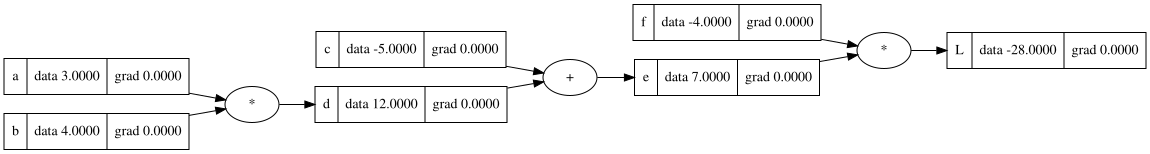

In [9]:
draw_dot(L) #forward pass

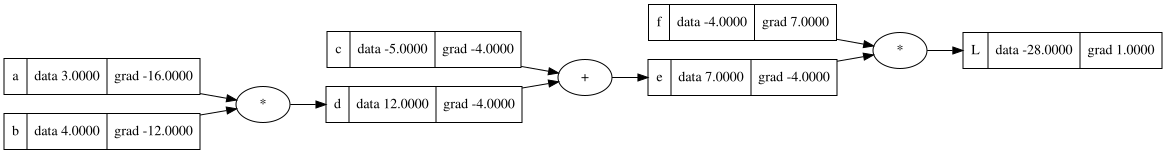

In [10]:
#manual backpropagation (backward pass)

L.grad = 1.00
e.grad = -4.00
f.grad = 7.00
c.grad = -4.00
d.grad = f.data
a.grad  = b.data * f.data
b.grad = a.data * f.data
draw_dot(L)

-23.498255999999998


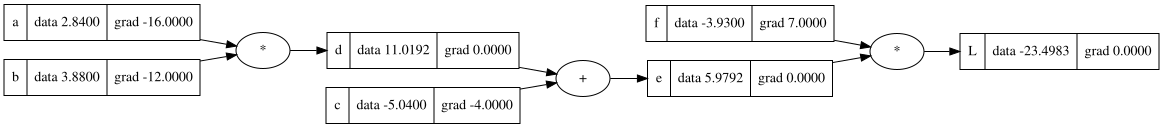

In [11]:

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

d = a*b; d.label = "d"
e = d + c; e.label = "e"
L = e * f ; L.label = "L"
print(L.data)
draw_dot(L)
# as we nudged L in a positive direction, the value of L became less negative (moved towards being positive)

In [12]:
#a
def func():
  h = 0.001 #tiny-change

  a = Value(3.0, label = "a")
  b = Value(4.0, label = "b")
  c = Value(-1*(5.0), label = "c")
  d = a*b; d.label = "d"
  e = d + c; e.label = "e"
  f = Value(-4.0, label = "f")
  L = e * f ; L.label = "L"
  L1 = L.data

  a = Value(3.0, label = "a")
  b = Value(4.0, label = "b")
  c = Value(-1*(5.0), label = "c")
  d = a*b; d.label = "d"
  e = d + c; e.label = "e"
  f = Value(-4.0, label = "f")
  L = e * f ; L.label = "L"
  L2 = L.data + h
  print((L2-L1)/h)
func()

1.0000000000012221


-2.0


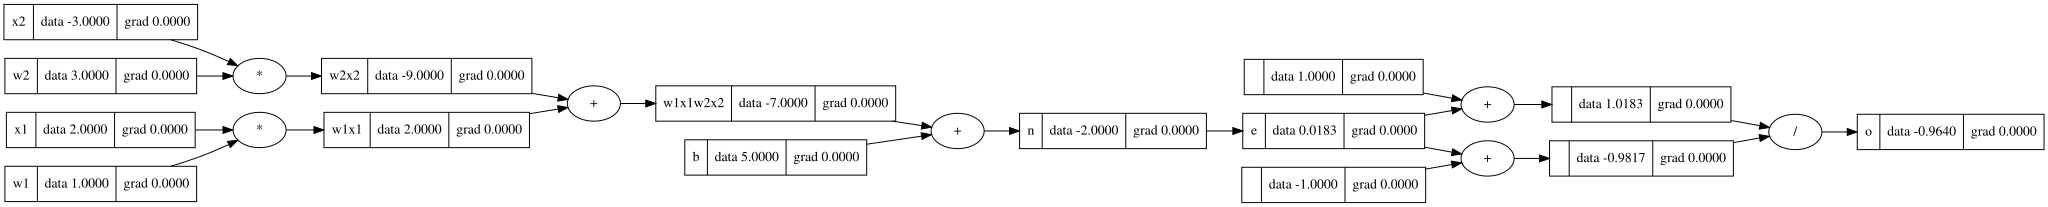

In [13]:
# neuron b

x1 = Value(2.0, label = "x1")
x2 = Value(-3.0, label  = "x2")
w1 = Value(1.0, label = "w1" )
w2 = Value(3.0, label = "w2")
b = Value(5.0, label = "b")
w1x1 = w1*x1; w1x1.label = "w1x1"
w2x2 = w2*x2; w2x2.label = "w2x2"
w1x1w2x2 = w1x1 + w2x2; w1x1w2x2.label = "w1x1w2x2"
n = w1x1w2x2 + b; n.label = "n"
''''o = n.tanh(); o.label = "o"'''
# insted of using tanh, which does not accumulate gradients properly, we'll now use a mathematically equivalent expression to replace tanh
e = n.exp(2) ; e.label = "e"
o = (e + (-1)) / (e+1); o.label = "o"
print(n.data)
draw_dot(o)

In [14]:
# manual backpropagation through the neuron
'''o.grad = 1
n.grad = 1-(o.data)**2
b.grad = n.grad; w1x1w2x2.grad = n.grad
w1x1.grad = n.grad; w2x2.grad = n.grad
w2.grad = x2.data * w1x1.grad; x2.grad = w2.data * w1x1.grad
w1.grad = x1.data * w2x2.grad; x1.grad = w1.data * w2x2.grad
draw_dot(o)'''

'o.grad = 1\nn.grad = 1-(o.data)**2\nb.grad = n.grad; w1x1w2x2.grad = n.grad\nw1x1.grad = n.grad; w2x2.grad = n.grad\nw2.grad = x2.data * w1x1.grad; x2.grad = w2.data * w1x1.grad\nw1.grad = x1.data * w2x2.grad; x1.grad = w1.data * w2x2.grad\ndraw_dot(o)'

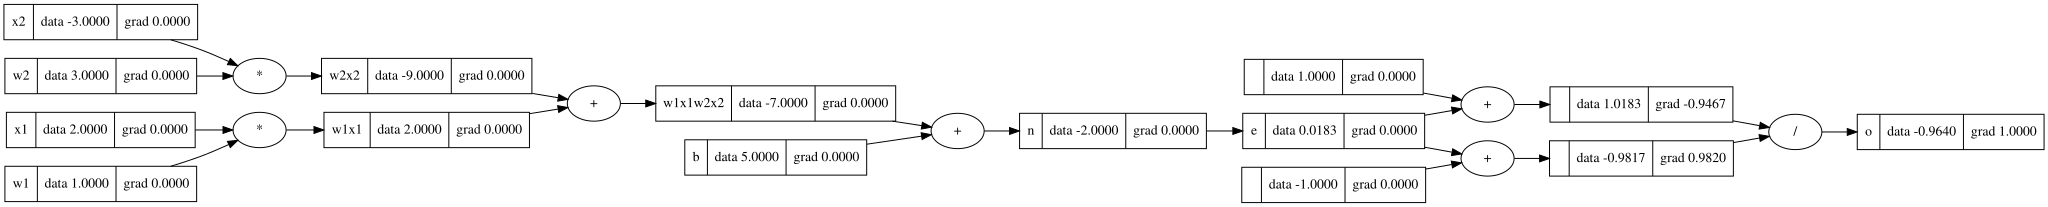

In [15]:
# backpropagation using the _backward function
o.grad = 1.0
o._backward() #backpropagates the gradient through the tanh function to n
e._backward() #backpropagates to e, which is also a node. (through division from o)
n._backward() #backpropagates the gradient through the + to w1x1w1x2 and b
b._backward() #does nothing, no children
w1x1w2x2._backward()
w1x1._backward()
w2x2._backward()

draw_dot(o)

In [16]:
#using topological sort to backpropagate the dependencies first:
topo = []
visited = set()
def build_topo(i):
  if i not in visited:
    visited.add(i)
    for v in i._prev:
      build_topo(v)
    topo.append(i)
build_topo(o)
topo





[Value(data=1),
 Value(data=1.0),
 Value(data=2.0),
 Value(data=2.0),
 Value(data=3.0),
 Value(data=-3.0),
 Value(data=-9.0),
 Value(data=-7.0),
 Value(data=5.0),
 Value(data=-2.0),
 Value(data=0.01831563888873418),
 Value(data=1.0183156388887342),
 Value(data=-1),
 Value(data=-0.9816843611112658),
 Value(data=-0.9640275800758169)]

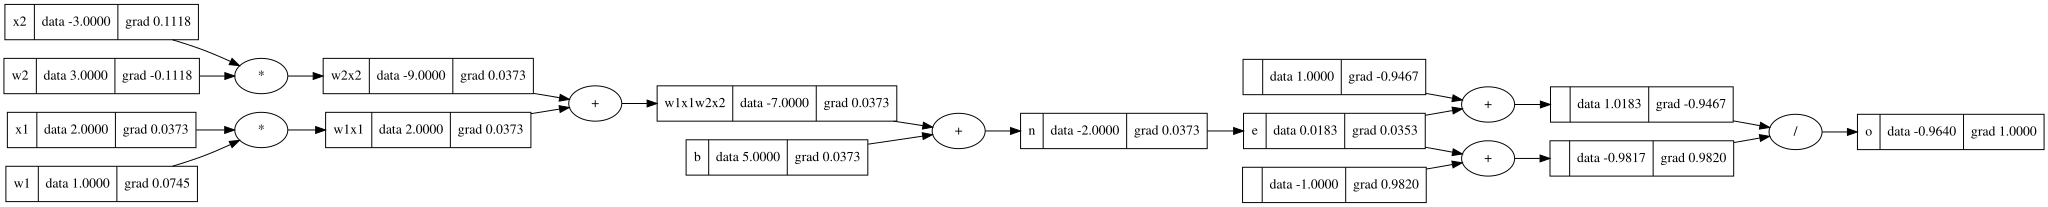

In [17]:
# completely automated backpropagation using topological sort
o.backward()
draw_dot(o)

In [18]:
p = Value(4.0, label = "p")
q = p + p; q.label = "q"


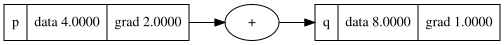

In [19]:
q.backward()
draw_dot(q)
# gradient doesn't accumulate !

In [20]:
#using pytorch
import torch

In [21]:
'''o.grad = 1
n.grad = 1-(o.data)**2
b.grad = n.grad; w1x1w2x2.grad = n.grad
w1x1.grad = n.grad; w2x2.grad = n.grad
w2.grad = x2.data * w1x1.grad; x2.grad = w2.data * w1x1.grad
w1.grad = x1.data * w2x2.grad; x1.grad = w1.data * w2x2.grad
draw_dot(o)'''

x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([3.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-2.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([-1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([0.3435323]).double()  ; b.requires_grad = True
n = w1*x1 + w2*x2 + b
o = torch.tanh(n)
o.backward()


In [22]:
print(x1.grad.item())

-1.3223735803746556e-05


In [23]:
class Neuron:
  def __init__(self, dim):
    self.w = list()
    for _ in range(dim): self.w.append(Value(random.uniform(-1, 1)))
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    activation = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = activation.tanh() #nonlinearizer
    return out

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts #concat arrays as nouts is a list of outputs, with the number of outputs denoting how large each layer is (more outputs if more neurons in one layer)
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__ (self, x):
    for layer in self.layers:   #for each layer in self.layers, the iterative is converted into a layer object
      x =  layer(x)
    return x






In [24]:
x = [2.0, 3.0, 7.0]
q = Neuron(3) # q  is 3D neuron
q(x)

l = Layer(3, 10) # 3 inputs to the neurons and 10 neurons in total in the layer, therefore yielding 10 values of the output as the nouts array.
l(x)


[Value(data=-0.9674438661449306),
 Value(data=0.9419466667412351),
 Value(data=-0.9313869532036894),
 Value(data=-0.9996640072673582),
 Value(data=0.9999880737448559),
 Value(data=-0.8004543834959237),
 Value(data=-0.8905011390271845),
 Value(data=-0.9959625963299529),
 Value(data=0.9385890925080437),
 Value(data=-0.9992603581832291)]

In [25]:
#MLP
n = MLP(3, [4, 4, 1]) # the output of each layer is chained into the next layer as inputs
n(x)

Value(data=0.42670892023634316)

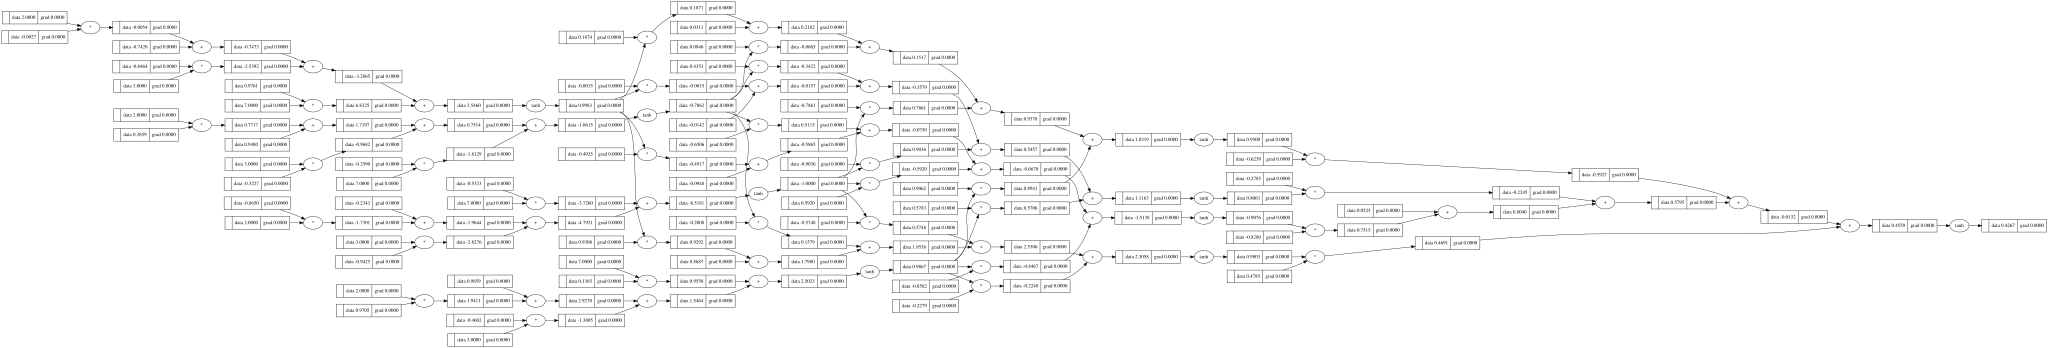

In [26]:
draw_dot(n(x))

In [45]:
#using a dataset and training the neural net:
dset = [[3.0, 2.0, 5.0],
        [4.0, 6.0, 3.0],
        [6.0, 7.8, 5.4]]

# using the neural net as a binary classifier, like the one used in the micrograd tutorial
exp =



In [46]:
#running the initial forward pass with this dataset on the MLP
g = MLP(3, [5, 5, 1])
#running the MLP on each data value
vals = [g(x) for x in dset]
vals

[Value(data=-0.7166695058986591),
 Value(data=-0.5832712363719755),
 Value(data=-0.5955570745007522)]

In [47]:
#calculating how far off each value is really from the expected values in exp
loss = [(o - f)**2 for o ,f in zip(exp, vals)] #Squared error



TypeError: 'Value' object is not iterable

In [44]:
draw_dot(lagg)

AttributeError: 'numpy.float64' object has no attribute '_prev'